In [1]:
# IMPORT LIBRARIES

In [2]:
import google.generativeai as genai
import json
import os
from datetime import datetime
import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from graphviz import Digraph
import faiss
from sentence_transformers import SentenceTransformer
from transformers import logging 
logging.set_verbosity_error()

In [3]:
# DEBUG MODE

DEBUG=True

In [4]:
# SETUP GEMINI API

In [36]:
API_KEY="YOUR_API_KEY"
genai.configure(api_key=API_KEY)

model=genai.GenerativeModel(
    model_name="gemini-2.5-flash",
    generation_config={
        "temperature":0.3,
        "max_output_tokens":1000
    }
)

print("Gemini 2.5 Flash ready!")


print("Gemini Ready!")
                                                                                                            

Gemini 2.5 Flash ready!
Gemini Ready!


In [6]:
# Architecture Diagram

PRINT-READY PNG saved: ET_AI_CONCIERGE_PRINT_READY.png
Size: High-resoulation(600 DPI) - Perfect for A4 printing!
Ready to print or use in documents!


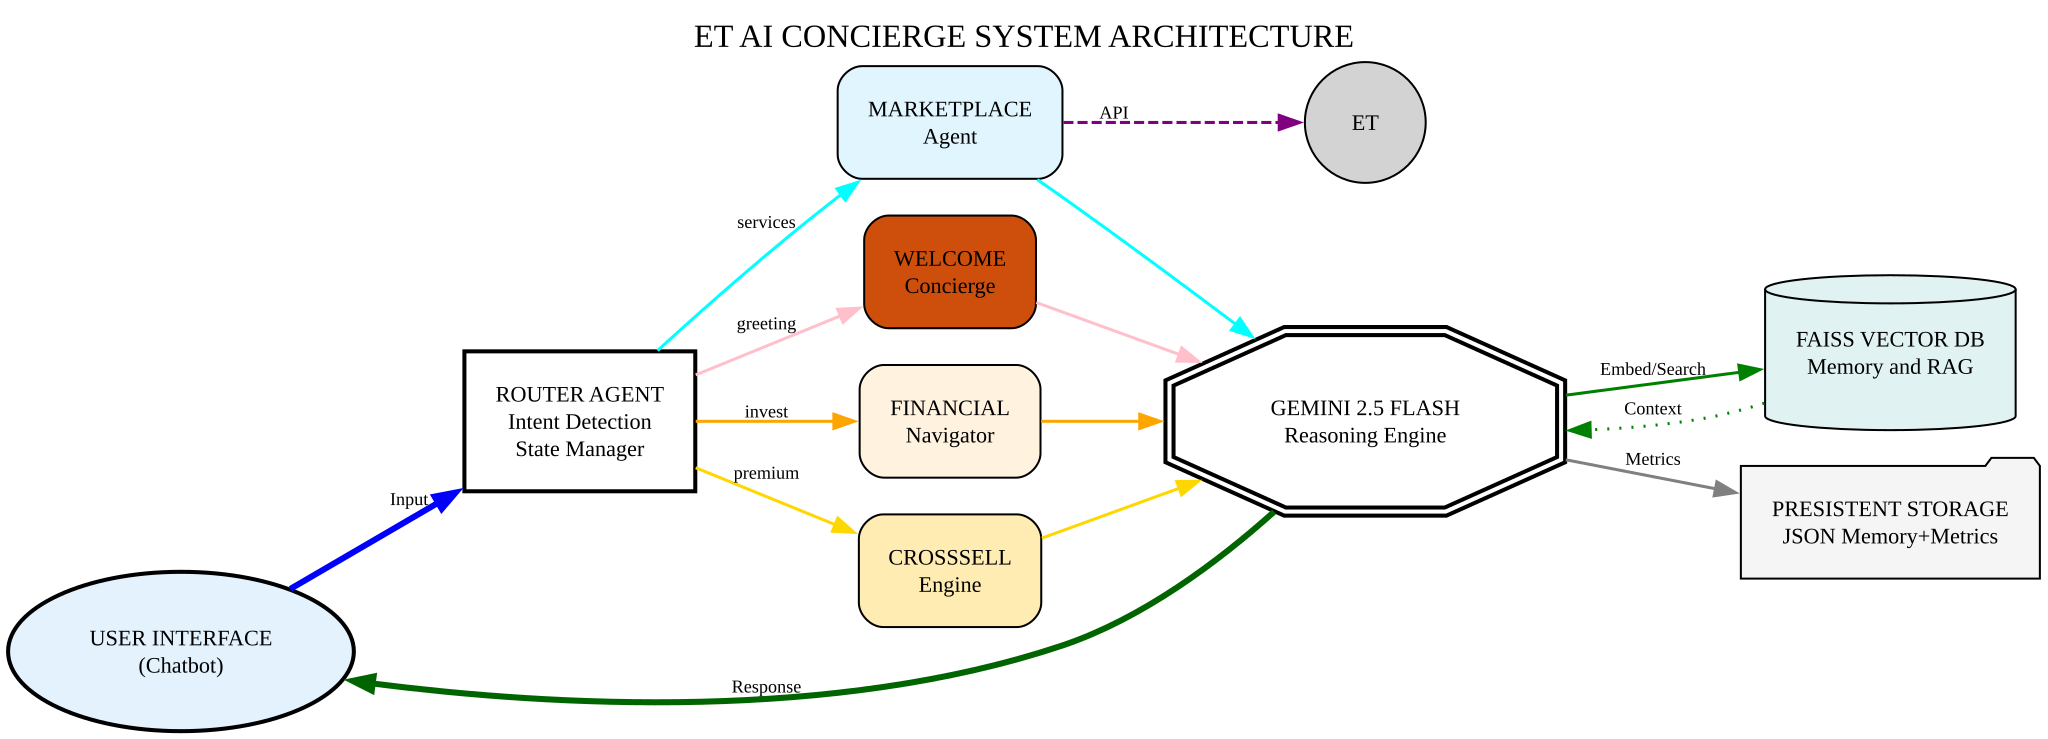

In [7]:
# GRAPHVIZ PATH 
os.environ["PATH"]+=os.pathsep+r"C:\Users\User\Downloads\windows_10_cmake_Release_Graphviz-14.1.3-win64\Graphviz-14.1.3-win64\bin"

# PRINT-READY RCHITECTURE DIAGRAM

dot = Digraph("ET_AI_CONCIERGE_PRINT", format="png",engine='dot')
dot.attr(rankdir='LR', size='16,10', dpi='300')
dot.attr('graph', bgcolor='white', fontsize='14')
dot.attr('node', fontsize='11', style='filled,rounded', margin='0.2')
dot.attr('edge', fontsize='9', penwidth='1.5')

# Title
dot.attr(label='ET AI CONCIERGE SYSTEM ARCHITECTURE',labelloc='t',fontsize='16')

# LAYER 1: USER
dot.node('USER','USER INTERFACE\n(Chatbot)',fillcolor='#E3F2FD', shape='ellipse',style='filled,bold')

# LAYER 2:ROUTER
with dot.subgraph(name='cluster_0') as c:
    c.attr(label='',style='filled',color='white')
    dot.node('ROUTER', 'ROUTER AGENT\nIntent Detection\nState Manager',fillcolor='#F3E5F5',shape='box',style='bold')

# LAYER 3: AGENTS
with dot.subgraph(name='cluster_1')as c:
    c.attr(label='SPECIALIZED AGENTS', style='filled', color='#E8F5E8')
    dot.node('WELCOME', 'WELCOME\nConcierge', fillcolor='#CE4EC', shape='box')
    dot.node('FINANCIAL', 'FINANCIAL\nNavigator', fillcolor='#FFF3E0', shape='box')
    dot.node('CROSSSELL', 'CROSSSELL\nEngine', fillcolor='#FFECB3', shape='box')
    dot.node('MARKETPLACE','MARKETPLACE\nAgent', fillcolor='#E1F5FE', shape='box')

# LAYER 4: CORE
with dot.subgraph(name='cluster_2')as c:
    c.attr(label='CORE AI ENGINE', style='filled', color='#FF8E1')
    dot.node('LLM', 'GEMINI 2.5 FLASH\nReasoning Engine', fillcolor='#FFF8D', shape='doubleoctagon', style='bold')
    dot.node('VECTOR', 'FAISS VECTOR DB\nMemory and RAG', fillcolor='#E0F2F1', shape='cylinder')

# LAYER 5: STORAGE
dot.node('STORAGE','PRESISTENT STORAGE\nJSON Memory+Metrics', fillcolor='#F5F5F5',shape='folder')

# LAYER 5: EXTERNAL
dot.edge('USER', 'ROUTER', label='Input', color='blue', penwidth='3')
dot.edge('ROUTER', 'WELCOME', label='greeting', color='pink')
dot.edge('ROUTER', 'FINANCIAL', label='invest', color='orange')
dot.edge('ROUTER', 'CROSSSELL', label='premium', color='gold')
dot.edge('ROUTER', 'MARKETPLACE', label='services', color='cyan')

dot.edge('WELCOME', 'LLM', color='pink')
dot.edge('FINANCIAL', 'LLM', color='orange')
dot.edge('CROSSSELL', 'LLM', color='gold')
dot.edge('MARKETPLACE', 'LLM', color='cyan')

dot.edge('LLM', 'VECTOR', label='Embed/Search', color='green', style='bold')
dot.edge('VECTOR', 'LLM', label='Context', color='green', style='dotted')
dot.edge('LLM', 'STORAGE', label='Metrics', color='gray')
dot.edge('MARKETPLACE', 'ET', label='API', color='purple', style='dashed')
dot.edge('LLM', 'USER', label='Response', color='darkgreen', penwidth='3')

# GENERATE PRINT=READY PNG
dot.render('ET_AI_CONCIERGE_PRINT_READY', format='png', cleanup=True,)
print("PRINT-READY PNG saved: ET_AI_CONCIERGE_PRINT_READY.png")
print("Size: High-resoulation(600 DPI) - Perfect for A4 printing!")
print("Ready to print or use in documents!")

# DISPLAY IN NOTEBOOK
dot

    

In [37]:
# MEMORY SYSTEM

MEMORY_FILE="et_concierge_memory.json"

def load_memory():
    if os.path.exists(MEMORY_FILE):
        with open(MEMORY_FILE,"r")as f:
            return json.load(f)
            return{"users": {}, "session": []}
            
def save_memory(memory):
    with open(MEMORY_FILE, "w")as f:
        json.dump(memory,f,indent=2)

memory=load_memory()
                    

In [38]:
# METRICS SYSTEM

METRICS_FILE="et_concierge_metrics.json"
def load_metrics():
    if os.path.exists(METRICS_FILE):
        with open(METRICS_FILE, "r") as f:
            return json.load(f)
            return{"sessions":0, "messages":0, "conversions":0}

def save_metrics(metrics):
    with open(METRICS_FILE, "w") as f:
        json.dump(metrics,f,indent=2)
        
metrics=load_metrics()
    

In [19]:
# VECTOR MEMORY

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
dimension = 384
index = faiss.IndexFlatL2(dimension)
conversation_memory = []

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [39]:
# STORE MEMORY

def store_memory(text):
    global index,conversation_memory
    try:
        embedding=embed_model.encode([text])
        index.add(embedding.astype('float32'))
        conversation_memory.append(text)
    except:pass
        

def retrieve_memory(query, k=3):
    if index.ntotal == 0:
        return ""
    try:
        embedding=embed_model.encode([query])
        distance,indices=index.search(embedding.astype('float32'), k)
        return "\n".join([conversation_memory[i] for i in indices[0] if i<len(conversation_memory)])
    except:return ""
                                 


In [40]:
# ROUTER AGENT

def router_agent(message):
    prompt=f"""
    CLASSIFY  into ONE category ONLY:
    1. Welcome(hello,hi,start,profile,goals)
    2. Financial(investment,portfolio,risk,stocks,analysis)
    3. CrossSell(premium,course,analytics,upgrade,pro)
    4. Marketplace(loan,insurance,card,mortgage,wealth)
    
    Message:"{message}"

    RETURN ONLY: Welcome OR Financial OR CrossSell OR  Marketplace
    """
    try:
        response = model.generate_content(prompt)
        category = response.text.strip().split()[0]
        return category
    except:
        return "Welcome"
        
    
      

In [41]:
# WELCOME AGENT

def welcome_agent(user_input,user_id="guest"):
    global memory, metrics
    if metrics is None:
        metrics = {"sessions":0, "messages":0, "conversions":0}

        metrics["sessions"] = metrics.get("sessions", 0) + 1
        metrics["messages"] = metrics.get("messages", 0)
        
        save_metrics(metrics)
        
        prompt=f"""
        you are ET Welcome Concierge.Be friendly and professional.
        Profile the user and ask about:
        1. Investment experience(beginner/inetermediate/advanced)
        2. Financial goals(retirement,house,education)
        3. Risk tolerance(low/medium/high)
        
        User:{user_input}
        keep response<150 words.
        """
    try:
        response=model.generate_content(prompt)
        return response.text
    except:
        return"Hi welcome to ET.what's your investment experience?(beginner/advanced)"

In [42]:
# FINANCIAL NAVIGATOR

def financial_agent(user_input):
    context = retrieve_memory(user_input)
    prompt = f"""
    You are ET Financial Navigator. Provide:
    -Personalized investment advice
    -Risk assessment
    -ET portfolio tools
    -Learning resources

    context:{context}
    user:{user_input}

    Be specific about ET features. Response<200 words.
    """
    response=model.generate_content(prompt)
    return response.text

In [43]:
# CROSS SELL ENGINE

def cross_sell_agent(user_input):
    prompt=f"""
    You are ET Cross-Sell Expert. Recommend PREMIUM ET products:
    1. Market Analytics Pro (999 rupees /mo)
    2.Investment Masterclass (4999 rupees)
    3.Portfolio Tracker Premium (299 rupees/mo)
    4.Research Reports (199 rupees/mo)

    user:{user_input}

    Create urgency.Include clear CTAs.<150 words.
    """
    response=model.generate_content(prompt)
    return response.text

In [44]:
# MARKETPLACE AGENT

def marketplace_agent(user_input):
    context = retrieve_memory(user_input)
    prompt=f"""
    You are ET Marketplace Agent.Recommend ET FINANCIAL PRODUCTS:
    1. Personal Loans (7.99% interest)
    2. Credit Cards (up to 5% cashback)
    3. Insurance (Life/Health/Car)
    4. Wealth Management(min 5L rupee)

    context:{context}
    user:{user_input}

    Include eligibilty, benefits, next steps. <200 words.
    """
    response=model.generate_content(prompt)
    return response.text

In [45]:
# MAIN AI CONCIERGE

def ai_concierge(message,history=None):
    global metrics
    if metrics is None:
        metrics={"messages": 0}
        metrics["messages"] += 1
        
        save_metrics(metrics)
        print(metrics)
    if DEBUG:
        print("\n USER:",message)
    try:
        # store user message
        store_memory(f"User: {message}")
        
        # Route intent
        intent=router_agent(message)
        if DEBUG:
            print("Intent:",intent)
        
        # Execute agent
        if intent== "Welcome":
            response=welcome_agent(message)
        elif intent=="Financial":
            response=financial_agent(message)
        elif intent== "CrossSell":
            response=cross_sell_agent(message)
        elif intent== "Marketplace":
            response=marketplace_agent(message)
        else:
            response = "Welcome to ET AI Concierge!Ask me about investments,loans,insurance or premium ET services!"

            # store AI response
            store_memory(f"AI: {response}")
            if DEBUG:
                print(f"AI: {response}")
                return response
    
    except Exception as e:
        return f"Apologies! Technical issue.Try:'hello' or 'investment advice'"  

In [46]:
# TEST FUNCTIONS

def test_router():
    print("\n Router Test")
    tests= ["hello", "invest money", "prenium course", "loan needed"]
    for t in tests:
        print(t, "->",
              router_agent(t))

def test_agents():
    print("\nAgents Test")
    print(welcome_agent("hello"))
    print(financial_agent("stocks"))
    print(cross_sell_agent("premium"))
    print(marketplace_agent("loan"))

def test_memory():
    print("\nMemory Test")
    store_memory("User likes stocks")
    print(retrieve_memory("stocks"))

def test_full():
    print("\nFull System Test")
    queries = ["hello", "invest", "premium", "loan"]
    for q in queries:
        print("\nUser:", q)
        print(f"AI:", ai_concierge(q))

# RUN TESTS

if __name__ == "__main__":
    test_router()
    test_agents()
    test_memory()
    test_full()
        
    


 Router Test
hello -> Welcome
invest money -> Financial
prenium course -> CrossSell
loan needed -> Marketplace

Agents Test
Hi welcome to ET.what's your investment experience?(beginner/advanced)
Hello! Interested in stocks? That's a great area to explore for wealth growth.

**Personalized Investment Advice:** For stocks, we recommend aligning your investments with your long-term goals and risk tolerance. Diversification across sectors and market caps is crucial. Always research companies thoroughly before investing.

**Risk Assessment:** Stocks carry inherent risks like market volatility, company-specific news, and economic downturns. Your portfolio's value can fluctuate significantly.

**ET Portfolio Tools:**
*   **ET Stock Screener:** Find stocks matching your specific criteria (e.g., industry, market cap, P/E ratio).
*   **ET Portfolio Tracker:** Monitor your stock holdings' performance, dividends, and real-time news.
*   **ET Watchlists:** Track potential stock investments before 

In [100]:
# PRODUCTION UI
def ai_concierge(msg):
    """Full ET - All services!"""
    msg=msg.lower().strip()
    
    # LOANS
    if "loan" in msg or "loans" in msg:
        return """
        **ET PERSONAL LOANS**
        Interest:**7.99%**
        Amount:₹50k-₹50 Lakhs
        Approval:Instant
        **Apply:**ET App/Website
        """
    # INVESTMENT
    if "invest" in msg or "investment" in msg:
        return """
        **ET INVESTMENT**
        **Top Picks:**
        -ET Bluechip Fund(12% avg)
        -ET Growth Stocks(20%+)
        -ET Dividend Portfolio (7% yield)

        **ET TOOLS:**
        -Portfolio Tracker(Free)
        -Risk Analyzer(Premium)

        **Start investment with ET!**
        """

    # PREMIUM
    # PREMIUM / CROSS-SELL
        
    if "premium" in msg or "pro" in msg:
        return"""
        **ET PREMIUM SERVICES**
        **Analytics Pro:** ₹999\mo
        -Real-time signals
        -Portfolio alerts
        **Masterclass:** ₹4,999
        -Investment strategies
        **Upgrade now - Limited offer!**
        """

    # INSURANCE
    if "insurance" in msg:
        return"""
        **ET Insurance:**
        **Health:** ₹10/day coverage
        **Car:**Comprehensive
        **Life:**Term plans
        
        **ET Benefits:**
        -Instant  quotes
        -Zero paperwork
        -Dedicated advisor
        **Get quote in ET App!**
        """

    # WELCOME
    if "hello" in msg or "hi" in msg:
        return"""
        "Welcome to ET AI Concierge!"






         

         
                


            
            
        
             
    
    
    
    
    
    
    
    
    
def chat(message,history):

    "Your Perfect chat function"""
    msg=str(message).strip()
    response=ai_concierge(message)
    history=history or []
    history.append({"role":"user","content":msg})
    history.append({"role":"assistant","content":response})
    return "", history
                        
            
        
    
with gr.Blocks(title="ET AI Concierge") as demo:
    
    gr.Markdown("# **ET AI Concierge**")
    
    
    
    gr.Markdown("Try: **Hello**| **Investments**| **Loans**| **Insurance** |**Premium Tools**")

    
    chatbot=gr.Chatbot(height=500)
    msg=gr.Textbox(
        placeholder=" Say 'hello' or ask: 'investment advice', 'personal loan', premium analytics'...",
        scale=7,
        lines=1
    )
    msg.submit(chat, [msg,chatbot], [msg,chatbot])
    
  
    

# Launch Production system
print("\n LAUNCHING ET AI CONCIERGE...")

demo.launch(share=True)       


 LAUNCHING ET AI CONCIERGE...
* Running on local URL:  http://127.0.0.1:7887
* Running on public URL: https://95e5f52f646ba7da00.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
